In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score
from itertools import combinations

This notebook focuses on Steps 1 and 2 of *Compare AI Exposure to AI Usage* and *Identify different AI transition archetypes* found in the [Concept Note](https://docs.google.com/document/d/1L5J0yp9uWzy_J4mkM9Ga62QGa-aa6oiG5bPMD9hmYCE/edit?usp=sharing) provided by Ms. Angela.

The granularity of the data is per SOC Occupation (where there 1,016 SOC occupations). However, due to privacy reasons (and also because apparently occupations related to military just really don't have data???), not all occupations have values (specifically on data which came from Anthropic.) They are held as null values.

# Step 1  - Compare AI Exposure to AI Usage

## a) Showing the Benefit of C-AIOE over AIOE as a way to measure Theoretical AI Exposure

### Definition of the Data and Metrics
Before comparing the metrics, we first define what each measure represents and what we expect to observe in the correlation matrix.

1. `AIOE` is the AI Occupational Exposure index from the World Bank. Its values range from approximately 5 to 7 in our dataset. Since AIOE is an index, the absolute value is less important than the relative exposure of occupations to one another.

2. `Complementarity` measures the extent to which AI is expected to complement or augment human work rather than automate it. The metric ranges from 0% to 100%, with higher values indicating greater potential for augmentation.

3. `C-AIOE` is our complementarity-adjusted AIOE measure. We interpret this as a theoretical measure of a job's potential risk of being automated or replaced by AI. Since C-AIOE incorporates both AI exposure and complementarity, we expect it to increase as AIOE increases and decrease as complementarity increases.

4. `Observed Exposure` is based on Anthropic's observed Claude usage data and is defined as the share of a job being performed or accelerated by an LLM. Because Anthropic's methodology incorporates [automation into the calculation of Observed Exposure](https://cdn.sanity.io/files/4zrzovbb/website/e5f77fc0e77c0185110b5e4b909602791ae76eae.pdf), higher automation should correspond to higher observed exposure. We therefore interpret this as an observed measure of a job's potential AI automation risk.

### Motivation of Choosing C-AIOE over AIOE as the Main Metric to Compare Against Observed Exposure
The motivation for using C-AIOE rather than AIOE when comparing against Observed Exposure is that the two measures should be compared on a similar conceptual basis. AIOE captures AI exposure alone, whereas Observed Exposure incorporates both exposure to AI and the extent to which AI can automate the work. C-AIOE similarly combines AI exposure with complementarity to produce a single measure that accounts for both dimensions. In other words, Observed Exposure combines exposure and complementarity-related information into one observed measure, while C-AIOE combines exposure and complementarity into one theoretical measure. Comparing C-AIOE with Observed Exposure therefore provides a more conceptually comparable comparison than using AIOE alone.

### Granularity

Of the 1,016 SOC codes available for this analysis, 756 (74%) have complete data for AIOE, Complementarity, C-AIOE, and Observed Exposure. The correlation analysis and visualizations in this step therefore use these 756 occupations.

In [2]:
ai_metrics_df = pd.read_csv('../data/auxiliary/soc_consolidated_ai_metrics.csv')

exposure_df = ai_metrics_df[['O*NET-SOC Code', 'Title', 'AIOE', 'Complementarity', 'C-AIOE', 'Observed Exposure']].dropna()

# get the data from Elondou
open_ai_df = pd.read_csv('../data/ai_measurements/occ_level.csv')
exposure_df = exposure_df.merge(open_ai_df, on='O*NET-SOC Code', how='left')

## b) Showing that there exists a big difference between AIOE and C-AIOE

### Definition of the Data and Metrics
TL;DR: For all columns, a higher value generally indicates greater AI exposure or risk, except for `Complementarity`, where a higher value indicates greater potential for AI to complement rather than substitute human work.

1. `nth Top AIOE (AIOE Rank)`

Indicates an occupation's ranking based on its AIOE value, where `1` represents the occupation with the highest AIOE. A lower rank therefore indicates greater AI exposure.

2. `nth Top C-AIOE (C-AIOE Rank)`

Follows the same ranking convention as `nth Top AIOE (AIOE Rank)`, but uses the complementarity-adjusted AIOE (C-AIOE). A lower rank indicates greater AI exposure after accounting for complementarity.

3. `Increase in Exposure (Rank Change)`

Represents the change in an occupation's rank between AIOE and C-AIOE. A positive value indicates that the occupation moved to a higher numerical rank, while a negative value indicates movement toward a lower numerical rank.

4. `Increase in Exposure (Rank Change) Percent`

Represents the percentage change in an occupation's ranking after adjusting AIOE for complementarity. Its interpretation follows the direction of `Rank Change`, with positive values indicating movement toward a higher numerical rank and negative values indicating movement toward a lower numerical rank.

### Main Insight
1. Although the median and mean rank changes are -10 and 0, the changes are still nontrivial to the standard deviation being 193. Hence, we should actually check what are the differences.
2. The differences can be seen by looking at the bottom and top 5 changes in rank. A positive change rank implies that a job became more exposed after accounting for complementarity and vice-versa. For a more general overview, we can also group by and take the averange change in rank for each occupation group. The biggest change were for Legal and Community & Social Development Occupations  where they became less by 3,928% and 1,481%.

In [3]:
exposure_df["nth Top AIOE (AIOE Rank)"] = (
    exposure_df["AIOE"]
    .rank(ascending=False, method="min")
).astype(int)

exposure_df["nth Top C-AIOE (C-AIOE Rank)"] = (
    exposure_df["C-AIOE"]
    .rank(ascending=False, method="min")
).astype(int)

exposure_df["Increase in Exposure (Rank Change)"] = -(
    exposure_df["nth Top C-AIOE (C-AIOE Rank)"] - 
    exposure_df["nth Top AIOE (AIOE Rank)"]
)

exposure_df["Increase in Exposure (Rank Change) Percent"] = (exposure_df["Increase in Exposure (Rank Change)"] / exposure_df["nth Top AIOE (AIOE Rank)"]) * 100
exposure_df = exposure_df.sort_values(by='Increase in Exposure (Rank Change) Percent', ascending=False)

In [4]:
exposure_df['Increase in Exposure (Rank Change)'].describe()

count    756.000000
mean       0.000000
std      193.166339
min     -553.000000
25%     -137.250000
50%      -10.000000
75%      130.000000
max      549.000000
Name: Increase in Exposure (Rank Change), dtype: float64

<Axes: >

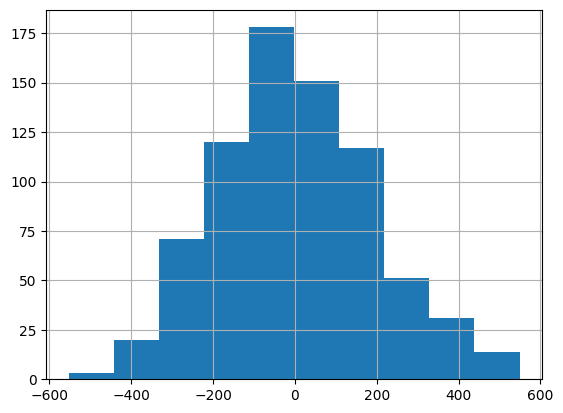

In [5]:
exposure_df['Increase in Exposure (Rank Change)'].hist()

In [6]:
exposure_df[
    [
        'O*NET-SOC Code', 
        'Title_x', 
        'nth Top AIOE (AIOE Rank)', 
        'nth Top C-AIOE (C-AIOE Rank)', 
        'Increase in Exposure (Rank Change)', 
        'Increase in Exposure (Rank Change) Percent'
    ]
]

,O*NET-SOC Code,Title_x,nth Top AIOE (AIOE Rank),nth Top C-AIOE (C-AIOE Rank),Increase in Exposure (Rank Change),Increase in Exposure (Rank Change) Percent
445,41-9041.00,Telemarketers,149,1,148,99.328859
491,43-9041.00,Insurance Claims and Policy Processing Clerks,181,3,178,98.342541
450,43-3011.00,Bill and Account Collectors,115,4,111,96.521739
461,43-4051.00,Customer Service Representatives,191,8,183,95.811518
62,13-2082.00,Tax Preparers,43,2,41,95.348837
...,...,...,...,...,...,...
179,23-1021.00,"Administrative Law Judges, Adjudicators, and H...",4,79,-75,-1875.000000
21,11-9033.00,"Education Administrators, Postsecondary",12,311,-299,-2491.666667
337,29-9092.00,Genetic Counselors,3,176,-173,-5766.666667
166,21-1013.00,Marriage and Family Therapists,1,152,-151,-15100.000000


In [7]:
# Add major group
major_groups = {
    "11": "Management",
    "13": "Business and Financial Operations",
    "15": "Computer and Mathematical",
    "17": "Architecture and Engineering",
    "19": "Life, Physical, and Social Science",
    "21": "Community and Social Service",
    "23": "Legal",
    "25": "Educational Instruction and Library",
    "27": "Arts, Design, Entertainment, Sports, and Media",
    "29": "Healthcare Practitioners and Technical",
    "31": "Healthcare Support",
    "33": "Protective Service",
    "35": "Food Preparation and Serving Related",
    "37": "Building and Grounds Cleaning and Maintenance",
    "39": "Personal Care and Service",
    "41": "Sales and Related",
    "43": "Office and Administrative Support",
    "45": "Farming, Fishing, and Forestry",
    "47": "Construction and Extraction",
    "49": "Installation, Maintenance, and Repair",
    "51": "Production",
    "53": "Transportation and Material Moving",
    "55": "Military"
}
exposure_df['Major Group'] = exposure_df['O*NET-SOC Code'].str[:2].map(major_groups)

In [8]:
grouped_occupations_exposure = exposure_df.groupby('Major Group')[['Increase in Exposure (Rank Change) Percent']].mean()
grouped_occupations_exposure.sort_values(by='Increase in Exposure (Rank Change) Percent')

,Increase in Exposure (Rank Change) Percent
Major Group,
Legal,-3928.702858
Community and Social Service,-1481.283134
Management,-225.707304
"Life, Physical, and Social Science",-187.265015
Healthcare Practitioners and Technical,-179.638051
Educational Instruction and Library,-170.490272
Business and Financial Operations,-74.101002
Architecture and Engineering,-71.446462
Protective Service,-28.599425


# c) Univariate & Bivariate Analysis of C-AIOE and Observed Exposure

C-AIOE is mostly bell-shaped while Observed Exposure has a very strong right skew where the median is just 0. In fact, 411 (54%) SOC codes have an Observed Exposure of 0. This would inform us later on that for both measures, it would be best to use the median as a possible threshold.

In [9]:
exposure_df[['C-AIOE', 'Observed Exposure']].describe()

,C-AIOE,Observed Exposure
count,756.000000,756.000000
mean,4.615395,0.076977
std,0.612283,0.133172
min,3.204920,0.000000
25%,4.175340,0.000000
50%,4.600775,0.000000
75%,5.066013,0.095675
max,6.270814,0.745100


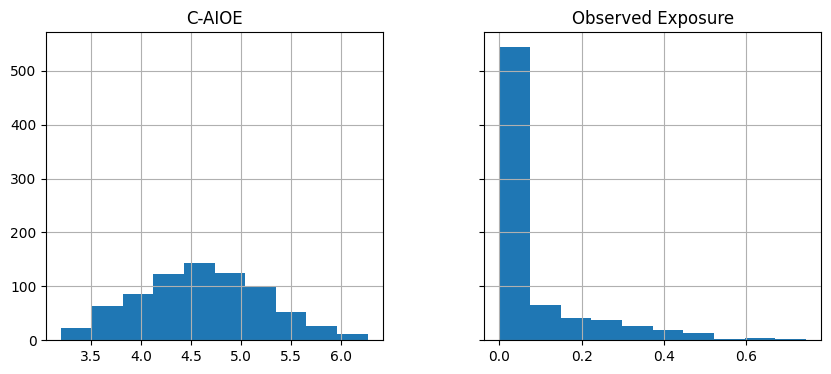

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
exposure_df[['C-AIOE', 'Observed Exposure']].hist(ax=axs)
plt.show()

For the bivariate relationship, the Pearson correlation between C-AIOE and Observed Exposure is 0.52, indicating a moderate positive linear association between the two measures. This relationship is notable because C-AIOE was constructed independently of Observed Exposure. For comparison, the Human Beta and Machine Beta measures, which are components used to construct Observed Exposure, have correlations of 0.59 and 0.64, respectively, with Observed Exposure. Thus, while C-AIOE has a weaker association with Observed Exposure than its constituent measures, its correlation of 0.52 still indicates a meaningful positive relationship between an independently constructed theoretical exposure measure and observed AI exposure.

In [11]:
exposure_df[['C-AIOE', 'dv_rating_beta', 'human_rating_beta', 'Observed Exposure']].corr()['Observed Exposure'].round(2)

C-AIOE               0.52
dv_rating_beta       0.64
human_rating_beta    0.59
Observed Exposure    1.00
Name: Observed Exposure, dtype: float64

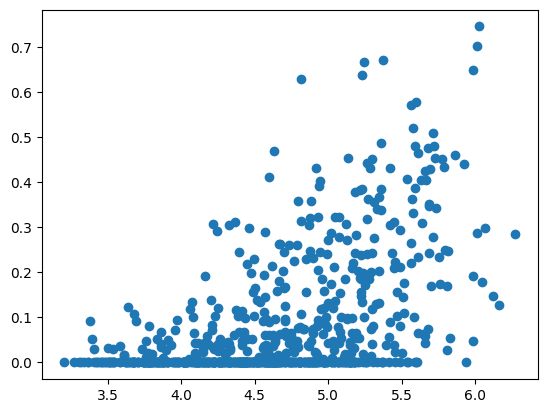

In [12]:
plt.scatter(exposure_df['C-AIOE'], exposure_df['Observed Exposure'])

# Step 2 - Identify different AI transition archetypes

## a) Identify the different AI transition archetypes based on the chosen Theoretical AI Exposure and Observed AI Exposure

The eventual objective is to determine which approach provides a more useful basis for identifying AI transition archetypes. In particular, we choose to have a percentile approach, where we transform $\text{C-AIOE}$ into a probability-scale measure so that it can be compared directly with Observed Exposure, which is already bounded between 0 and 1. We just did empirical percentile of $\text{C-AIOE}$ so that the transformed metric is also bounded between 0 and 1.


In [13]:
# get the percentile for the C-AIOE
exposure_df["C-AIOE Percentile"] = exposure_df["C-AIOE"].rank(pct=True)

In [14]:
def classify_transition_archetype(
    job: pd.Series,
    theoretical_column: str,
    exposure_df: pd.DataFrame = exposure_df,
) -> str:
    """Classify a job into an AI transition archetype.

    Classification is based on whether the job's theoretical AI
    exposure and observed AI exposure are below or above their
    respective medians across all occupations.

    Args:
        job: A pandas Series representing a single occupation.
        theoretical_column: Name of the theoretical AI exposure
            column used for classification.
        exposure_df: DataFrame containing AI exposure measures
            across occupations.

    Returns:
        The AI transition archetype assigned to the job.
    """
    # get the medians
    theoretical_median = exposure_df[theoretical_column].median()
    observed_exposure_median = exposure_df["Observed Exposure"].median()

    # get the job's actual theoretical and observed job exposure
    theoretical_job = job[theoretical_column]
    observed_exposure_job = job["Observed Exposure"]

    # create the boolean
    theoretical_exposure_low = theoretical_job <= theoretical_median
    observed_exposure_low = observed_exposure_job <= observed_exposure_median

    if theoretical_exposure_low:
        if observed_exposure_low:
            return "Limited Current Transformation" # low theoretical and observed
        return "AI-Enabled Expansion" # low theoretical but high observed

    if observed_exposure_low:
        return "Latent Transformation" # high theoretical but low observed

    return "Active Transformation" # high theoretical and observed

## b) Determining if there exists reasonably stable AI transition archetypes

To determine whether reasonably stable AI transition archetypes exist, we use Cohen's Kappa ($\kappa$) to measure the agreement between the classifications produced by different theoretical exposure measures. Cohen's Kappa measures agreement between two categorical classifications while accounting for the agreement that would be expected by chance. The statistic ranges from $-1$ to $1$, where $1$ represents perfect agreement and $0$ represents agreement equivalent to chance. Under the commonly used interpretation of Landis and Koch (1977), values between $0.41$ and $0.60$ represent moderate agreement.

We therefore define an AI transition archetype classification as reasonably stable when the Cohen's Kappa between the archetypes derived from C-AIOE and those derived from the selected benchmark theoretical exposure measure is greater than $0.41$, corresponding to at least moderate agreement under this interpretation.

For the benchmark comparison, we use the Human and LLM Beta measure developed in Labor market impacts of AI: A new measure and early evidence by Massenkoff and McCrory [(2026)](https://www.anthropic.com/research/labor-market-impacts). This measure is selected because it was used as a theoretical exposure measure in the study's comparison of theoretical AI exposure with observed AI exposure. The Human and LLM Beta measure therefore provides a relevant benchmark for evaluating whether the transition archetypes identified using C-AIOE are consistent with Anthropic's (i.e., [Elondou's](https://arxiv.org/abs/2303.10130)) theoretical exposure framework.

In [23]:
theoretical_exposure_measurments = [
    #"AIOE",
    #"C-AIOE",
    "C-AIOE Percentile",
    #"Observed Exposure",
    #"dv_rating_alpha",
    "dv_rating_beta",
    #"dv_rating_gamma",
    #"human_rating_alpha",
    "human_rating_beta",
    #"human_rating_gamma",
]


# apply and classify each job into a transition archetype
archetype_columns = [
    f"Archetype {measurement}"
    for measurement in theoretical_exposure_measurments
]
for theoretical_exposure_measurment in theoretical_exposure_measurments:
    col_name = "Archetype " + theoretical_exposure_measurment
    exposure_df[col_name] = exposure_df.apply(
        classify_transition_archetype,
        theoretical_column=theoretical_exposure_measurment,
        axis=1
    )

In [24]:
kappas = {'Archetype 1':[], 'Archetype 2': [], "Cohen's Kappa": []}
for measurement1, measurement2 in combinations(archetype_columns, 2):
    kappa = cohen_kappa_score(
        exposure_df[measurement1], exposure_df[measurement2]
    )
    kappas['Archetype 1'].append(measurement1)
    kappas['Archetype 2'].append(measurement2)
    kappas["Cohen's Kappa"].append(kappa)

kappas_df = pd.DataFrame(kappas)

In [25]:
kappas_df.sort_values(by="Cohen's Kappa")

,Archetype 1,Archetype 2,Cohen's Kappa
0,Archetype C-AIOE Percentile,Archetype dv_rating_beta,0.575428
1,Archetype C-AIOE Percentile,Archetype human_rating_beta,0.587012
2,Archetype dv_rating_beta,Archetype human_rating_beta,0.830221
